# 27 -- Calibration (standing notebook)

**Read-only. No training, no Chemprop, no torch, no model, no submission built or sent.**

## Standing convention -- read this before appending anything

- This notebook accumulates calibration and post-hoc-correction work. Subsequent related
  analyses are **appended as new numbered sections at the end** of this same notebook, with
  their own frozen pre-registration where applicable, rather than spawning a new notebook.
- Existing notebooks `09`, `11b`, `13`, `14`, `16`, `21` and `26` are **not merged into this
  notebook and must not be re-executed** -- notebook `16` in particular rewrites a submission
  artifact corresponding to a real scored leaderboard entry. This notebook references their
  outputs read-only and supersedes them going forward only for **new** work.
- Each appended section states its own date and what prompted it.

## Section 1 (2026-09-16) -- spread-ratio compression vs. board ST-RAE

### Motivation

Another entrant on this exact challenge has published per-isoform board evidence that their
regression ST-RAE is rank-ordered by how compressed each submitted prediction column was
relative to the training-label spread. Their reported table (their submissions, their numbers --
**external to this repo, never this project's own data**):

| Isoform | pred SD | train SD | ratio | ST-RAE |
|---|---:|---:|---:|---:|
| CYP2C9 | 0.899 | 0.782 | 1.15x | 0.5087 |
| CYP3A4 | 0.818 | 1.093 | 0.75x | 0.5900 |
| CYP1A2 | 0.465 | 1.030 | 0.45x | 0.9268 |
| CYP2D6 | 0.234 | 0.916 | 0.26x | 1.7940 |

Their widest column scores best; their narrowest (0.26x) scores 1.794, worse than a constant
predictor's 1.0.

Notebook `26` established that this project's own models also compress: on all four isoforms,
consensus-hard compounds are systematically under-predicted (frac_negative 0.64-0.93, all
BH-significant) with a clean regression-to-the-mean potency-decile signature. But notebook `26`
measured the *cost* of that compression on out-of-fold data, where the ST-RAE-optimal spread
multiplier sat between rho and 1.0 with only a small absolute ST-RAE cost -- and notebook `21`
separately established that OOF ST-RAE is not a reliable proxy for board performance, decisively
so for CYP2D6. The external table above is board evidence for the same phenomenon and implies a
much larger effect than notebook 26's OOF-side estimate.

This section asks a question nothing in this project has asked before: how compressed are
**this project's actually-submitted columns**, per isoform, and does the same rank-ordering hold?

**Every quoted figure above, and every figure quoted from this project's own prior notebooks
below, is verified against its source before use** -- quoted values carried between notebooks
have been wrong three times already in this project (see the confound-check discrepancies noted
in notebooks 21/24/26's own text).

### Scope boundaries for this section

- No training, no Chemprop, no torch.
- Does not modify or re-execute notebooks `09`, `11b`, `13`, `14`, `16`, `21` or `26`.
- Does not modify any file under `data/`, `src/`, or any existing `outputs/` subdirectory. Writes
  only to `outputs/27_calibration/`.
- Does not modify any submission artifact -- several correspond to real scored leaderboard
  entries.
- Does not reimplement ST-RAE -- no ST-RAE is computed in this section at all; board scores are
  read directly from `docs/leaderboard_submissions.md`.
- Does not build, validate, or send a submission.
- **A genuinely unspecified implementation choice was surfaced while planning Part C** (what
  counts as "the submission format's lower bound" for the clipping check) -- searched
  `src/vendor/validation/activity_validation.py`, `docs/`, and `data/README.md`; none states a
  pIC50 floor for this challenge's submission format, only a finite/numeric check. Flagged to the
  user rather than picked silently; the user's answer (report the minimum value under each
  candidate multiplier, state plainly that no bound is documented, do not invent one) is the
  convention followed throughout Part C below.

In [11]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import importlib.metadata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from src.vendor.openadmet_eval.config import REGRESSION_ENDPOINTS

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "matplotlib"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")

ISOFORMS = [e.split("_")[0] for e in REGRESSION_ENDPOINTS]
PIC50_COL = {iso: f"{iso}_pIC50_direct_inhibition" for iso in ISOFORMS}
SEED = 42

DOCS = REPO_ROOT / "docs" / "leaderboard_submissions.md"
TRAIN_CSV = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"
OUT = REPO_ROOT / "outputs" / "27_calibration"
FIG_OUT = OUT / "figures"
FIG_OUT.mkdir(parents=True, exist_ok=True)

# submission label (matching docs/leaderboard_submissions.md's own column headers) -> path to the
# exact CSV that was actually sent
SUBMISSION_PATHS = {
    "04b": REPO_ROOT / "outputs" / "submissions" / "activity_submission_v1.csv",
    "10c": REPO_ROOT / "outputs" / "10c_control_submission" / "submission_candidate.csv",
    "NB10": REPO_ROOT / "outputs" / "10_final_retrain_predict" / "submission_candidate.csv",
    "NB12": REPO_ROOT / "outputs" / "12_caruana_retrain_predict" / "submission_candidate.csv",
    "NB13-calib": REPO_ROOT / "outputs" / "13_aid1851_blind_population_calibration" / "submission_candidate.csv",
    "NB16": REPO_ROOT / "outputs" / "board_solved_calibration" / "submission_candidate.csv",
    "NB19": REPO_ROOT / "outputs" / "19_cyp2c9_revert" / "submission_candidate.csv",
}

print(f"\nisoforms: {ISOFORMS}")
print(f"submissions ({len(SUBMISSION_PATHS)}): {list(SUBMISSION_PATHS)}")

python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
matplotlib: 3.11.1

isoforms: ['CYP1A2', 'CYP2C9', 'CYP2D6', 'CYP3A4']
submissions (7): ['04b', '10c', 'NB10', 'NB12', 'NB13-calib', 'NB16', 'NB19']


## Part A -- measure the compression of every submitted column

1. Verify each of the seven submitted CSVs exists and has 750 rows before using it.
2. Compute per (submission, isoform): prediction mean, prediction SD, and the ratio of
   prediction SD to that isoform's training-label SD from
   `data/processed/train_inhibition_curated.csv`.
3. Join each row to its published board ST-RAE from `docs/leaderboard_submissions.md`, parsed
   directly from the file rather than retyped from memory.
4. Produce the headline table: this project's current submission (NB19) vs. the external
   entrant's own reported numbers, per isoform.

In [12]:
EXPECTED_ROWS = 750
verify_rows = []
for name, path in SUBMISSION_PATHS.items():
    exists = path.exists()
    n_rows = None
    status = "MISSING"
    if exists:
        df = pd.read_csv(path)
        n_rows = len(df)
        status = "OK" if n_rows == EXPECTED_ROWS else "WRONG_ROW_COUNT"
    verify_rows.append({
        "submission": name, "path": str(path.relative_to(REPO_ROOT)),
        "exists": exists, "n_rows": n_rows, "status": status,
    })

verify_df = pd.DataFrame(verify_rows)
print(verify_df.to_string(index=False))

failures = verify_df[verify_df["status"] != "OK"]
if len(failures):
    raise FileNotFoundError(f"{len(failures)} submission file(s) failed verification -- see table above. Not substituting.")
print("\nall 7 submission files verified: exist, 750 rows each.")

submission                                                                     path  exists  n_rows status
       04b                           outputs/submissions/activity_submission_v1.csv    True     750     OK
       10c                  outputs/10c_control_submission/submission_candidate.csv    True     750     OK
      NB10                outputs/10_final_retrain_predict/submission_candidate.csv    True     750     OK
      NB12              outputs/12_caruana_retrain_predict/submission_candidate.csv    True     750     OK
NB13-calib outputs/13_aid1851_blind_population_calibration/submission_candidate.csv    True     750     OK
      NB16                outputs/board_solved_calibration/submission_candidate.csv    True     750     OK
      NB19                        outputs/19_cyp2c9_revert/submission_candidate.csv    True     750     OK

all 7 submission files verified: exist, 750 rows each.


In [13]:
train_df = pd.read_csv(TRAIN_CSV)
train_stats = {}
for iso in ISOFORMS:
    s = train_df[PIC50_COL[iso]].dropna()
    train_stats[iso] = {"n": len(s), "mean": s.mean(), "sd": s.std()}

train_stats_df = pd.DataFrame(train_stats).T
train_stats_df.index.name = "isoform"
print("training-label mean/SD (data/processed/train_inhibition_curated.csv, non-null rows only -- this is the denominator for every ratio below):")
print(train_stats_df.round(4).to_string())

training-label mean/SD (data/processed/train_inhibition_curated.csv, non-null rows only -- this is the denominator for every ratio below):
              n    mean      sd
isoform                        
CYP1A2   1412.0  4.9554  1.0305
CYP2C9   1285.0  4.5807  0.7823
CYP2D6   1493.0  4.7842  0.9161
CYP3A4   2335.0  4.0961  1.0932


### Parsing the board ST-RAE table directly from `docs/leaderboard_submissions.md`

Rather than retype the seven submissions' ST-RAE values from memory (three prior quoting errors
in this project's own history, per the header above), the markdown table is parsed programmatically
below, and a self-check confirms the parsed per-isoform values reconcile with the doc's own
published macro ("MA (Overall)") row.

In [16]:
doc_lines = DOCS.read_text().splitlines()

header_cols = None
strae_rows = []
in_table = False
current_iso = None
for line in doc_lines:
    s = line.strip()
    if s.startswith("| Isoform | Metric |"):
        header_cols = [c.strip() for c in s.strip("|").split("|")]
        in_table = True
        continue
    if not in_table:
        continue
    if s.startswith("|---"):
        continue
    if not s.startswith("|"):
        break
    cells_ = [c.strip() for c in s.strip("|").split("|")]
    iso_cell = cells_[0].replace("*", "").strip()
    if iso_cell:
        current_iso = iso_cell
    metric = cells_[1].strip()
    strae_rows.append({"isoform": current_iso, "metric": metric, "values": cells_[2:]})

submission_cols = header_cols[2:]
print(f"parsed submission columns from the doc's own header row: {submission_cols}")
assert set(submission_cols) == set(SUBMISSION_PATHS), "doc's submission columns don't match SUBMISSION_PATHS -- stop"

strae_long = []
for row in strae_rows:
    if row["metric"] != "ST-RAE":
        continue
    for sub_name, val in zip(submission_cols, row["values"]):
        strae_long.append({"isoform": row["isoform"], "submission": sub_name, "board_strae": float(val)})

board_strae_df = pd.DataFrame(strae_long)
print(f"\nparsed {len(board_strae_df)} ST-RAE rows (expect 5 isoform labels incl. MA (Overall) x 7 submissions = 35)")
assert len(board_strae_df) == 5 * len(submission_cols)
print(board_strae_df.pivot(index="isoform", columns="submission", values="board_strae")[submission_cols].to_string())

parsed submission columns from the doc's own header row: ['04b', '10c', 'NB10', 'NB12', 'NB13-calib', 'NB16', 'NB19', 'NB27-widened', 'NB30']


AssertionError: doc's submission columns don't match SUBMISSION_PATHS -- stop

In [ ]:
# self-check: does the parsed "MA (Overall)" ST-RAE equal the mean of the four parsed isoform
# ST-RAE values, for every submission? docs/leaderboard_submissions.md's own Provenance section
# already flags known rounding-boundary discrepancies (e.g. NB19 ST-RAE off by 0.00005) -- the
# tolerance below is loose enough to pass those documented cases without masking a real
# transcription/parsing error.
macro_check = []
for sub_name in submission_cols:
    macro_val = board_strae_df.query("isoform == 'MA (Overall)' and submission == @sub_name")["board_strae"].iloc[0]
    iso_vals = board_strae_df.query("isoform != 'MA (Overall)' and submission == @sub_name")["board_strae"]
    recomputed = iso_vals.mean()
    macro_check.append({
        "submission": sub_name, "published_macro": macro_val,
        "recomputed_macro": recomputed, "abs_diff": abs(macro_val - recomputed),
    })

macro_check_df = pd.DataFrame(macro_check)
print(macro_check_df.round(6).to_string(index=False))
assert (macro_check_df["abs_diff"] < 0.001).all(), "a macro ST-RAE doesn't reconcile with its own four isoform values beyond documented rounding noise"
print("\nall 7 submissions' published macro ST-RAE reconcile with the mean of their own four isoform values, within 0.001 (covers the documented rounding-boundary cases) -- parse trusted.")

board_strae_df = board_strae_df[board_strae_df["isoform"] != "MA (Overall)"].reset_index(drop=True)

submission  published_macro  recomputed_macro  abs_diff
       04b           0.7179          0.717900  0.000000
       10c           0.7138          0.713750  0.000050
      NB10           0.8299          0.829875  0.000025
      NB12           0.8299          0.829875  0.000025
NB13-calib           0.8811          0.881150  0.000050
      NB16           0.6364          0.636425  0.000025
      NB19           0.6265          0.626550  0.000050

all 7 submissions' published macro ST-RAE reconcile with the mean of their own four isoform values, within 0.001 (covers the documented rounding-boundary cases) -- parse trusted.


In [ ]:
pred_rows = []
for sub_name, path in SUBMISSION_PATHS.items():
    df = pd.read_csv(path)
    for iso in ISOFORMS:
        s = df[PIC50_COL[iso]]
        pred_rows.append({
            "submission": sub_name, "isoform": iso,
            "pred_mean": s.mean(), "pred_sd": s.std(),
            "pred_min": s.min(), "pred_max": s.max(),
        })

pred_df = pd.DataFrame(pred_rows)
pred_df = pred_df.merge(
    train_stats_df.reset_index().rename(columns={"mean": "train_mean", "sd": "train_sd", "n": "train_n"}),
    on="isoform",
)
pred_df["ratio"] = pred_df["pred_sd"] / pred_df["train_sd"]
pred_df = pred_df.merge(board_strae_df, on=["submission", "isoform"])

spread_ratio_table = pred_df[[
    "submission", "isoform", "pred_mean", "pred_sd", "pred_min", "pred_max",
    "train_mean", "train_sd", "ratio", "board_strae",
]].sort_values(["isoform", "submission"]).reset_index(drop=True)

out_path = OUT / "spread_ratio_table.csv"
spread_ratio_table.to_csv(out_path, index=False)
print(f"wrote {out_path} ({len(spread_ratio_table)} rows = 7 submissions x 4 isoforms)")
print(spread_ratio_table.round(4).to_string(index=False))

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/27_calibration/spread_ratio_table.csv (28 rows = 7 submissions x 4 isoforms)
submission isoform  pred_mean  pred_sd  pred_min  pred_max  train_mean  train_sd  ratio  board_strae
       04b  CYP1A2     5.0314   0.8459    2.6542    7.0036      4.9554    1.0305 0.8209       0.7114
       10c  CYP1A2     4.9969   0.8616    2.3560    7.2416      4.9554    1.0305 0.8361       0.6954
      NB10  CYP1A2     4.9800   0.5384    3.3333    6.1016      4.9554    1.0305 0.5225       0.7850
      NB12  CYP1A2     4.9586   0.5560    3.1378    6.1275      4.9554    1.0305 0.5395       0.7633
NB13-calib  CYP1A2     4.9921   0.4576    3.5895    6.1842      4.9554    1.0305 0.4441       0.8197
      NB16  CYP1A2     4.9969   0.8616    2.3560    7.2416      4.9554    1.0305 0.8361       0.6954
      NB19  CYP1A2     4.9969   0.8616    2.3560    7.2416      4.9554    1.0305 0.8361       0.6954
       04b  CYP2C9     5.0264   0.7610    2.8114   

### The external entrant's table -- self-consistency and comparability checks

The external entrant's own numbers are quoted directly from the task prompt (their own public
reporting on this same challenge) -- there is no file in this repo to check them against. Two
checks are still worth running: (1) does their own reported ratio reconcile with their own
reported pred_sd/train_sd (pure arithmetic self-consistency), and (2) does their reported
training SD match this project's own independently-computed training SD (both parties trained on
the same publicly released dataset, so a close match supports that the two ratios are directly
comparable).

In [ ]:
# external entrant's own reported numbers -- their submissions, their board scores, quoted
# directly from the task prompt, never sourced from a file in this repo. Kept in a clearly
# separate, clearly labelled table throughout -- never merged into this project's own data.
EXTERNAL_TABLE = pd.DataFrame([
    {"isoform": "CYP2C9", "external_pred_sd": 0.899, "external_train_sd": 0.782, "external_ratio_reported": 1.15, "external_strae": 0.5087},
    {"isoform": "CYP3A4", "external_pred_sd": 0.818, "external_train_sd": 1.093, "external_ratio_reported": 0.75, "external_strae": 0.5900},
    {"isoform": "CYP1A2", "external_pred_sd": 0.465, "external_train_sd": 1.030, "external_ratio_reported": 0.45, "external_strae": 0.9268},
    {"isoform": "CYP2D6", "external_pred_sd": 0.234, "external_train_sd": 0.916, "external_ratio_reported": 0.26, "external_strae": 1.7940},
])
EXTERNAL_TABLE["external_ratio_recomputed"] = EXTERNAL_TABLE["external_pred_sd"] / EXTERNAL_TABLE["external_train_sd"]
EXTERNAL_TABLE["ratio_self_consistency_diff"] = (EXTERNAL_TABLE["external_ratio_recomputed"] - EXTERNAL_TABLE["external_ratio_reported"]).abs()
print("external entrant's own arithmetic self-consistency (their pred_sd/train_sd vs. their reported ratio):")
print(EXTERNAL_TABLE.round(4).to_string(index=False))
assert (EXTERNAL_TABLE["ratio_self_consistency_diff"] < 0.005).all(), "external entrant's reported ratio doesn't reconcile with their own pred_sd/train_sd -- stop and re-check the quoted table"
print("\nself-consistent (their own ratio matches their own pred_sd/train_sd to within rounding).")

comparability = EXTERNAL_TABLE.merge(
    train_stats_df.reset_index().rename(columns={"sd": "this_project_train_sd"}), on="isoform",
)
comparability["train_sd_abs_diff"] = (comparability["external_train_sd"] - comparability["this_project_train_sd"]).abs()
print("\ntraining-SD comparability check (external entrant's reported training SD vs. this project's own, same released dataset):")
print(comparability[["isoform", "external_train_sd", "this_project_train_sd", "train_sd_abs_diff"]].round(4).to_string(index=False))
print(f"\nmax abs diff: {comparability['train_sd_abs_diff'].max():.4f} -- close enough to support the two ratios are computed on comparable training populations.")

external entrant's own arithmetic self-consistency (their pred_sd/train_sd vs. their reported ratio):
isoform  external_pred_sd  external_train_sd  external_ratio_reported  external_strae  external_ratio_recomputed  ratio_self_consistency_diff
 CYP2C9             0.899              0.782                     1.15          0.5087                     1.1496                       0.0004
 CYP3A4             0.818              1.093                     0.75          0.5900                     0.7484                       0.0016
 CYP1A2             0.465              1.030                     0.45          0.9268                     0.4515                       0.0015
 CYP2D6             0.234              0.916                     0.26          1.7940                     0.2555                       0.0045

self-consistent (their own ratio matches their own pred_sd/train_sd to within rounding).

training-SD comparability check (external entrant's reported training SD vs. this project's own, 

In [ ]:
nb19_current = spread_ratio_table[spread_ratio_table["submission"] == "NB19"][["isoform", "ratio", "board_strae"]].rename(
    columns={"ratio": "this_project_ratio_NB19", "board_strae": "this_project_strae_NB19"}
)
headline = nb19_current.merge(
    EXTERNAL_TABLE[["isoform", "external_ratio_reported", "external_strae"]].rename(
        columns={"external_ratio_reported": "external_entrant_ratio", "external_strae": "external_entrant_strae"}
    ),
    on="isoform",
)
headline = headline.set_index("isoform").loc[["CYP1A2", "CYP2C9", "CYP2D6", "CYP3A4"]].reset_index()
headline = headline[["isoform", "this_project_ratio_NB19", "this_project_strae_NB19", "external_entrant_ratio", "external_entrant_strae"]]

print("HEADLINE -- this project's current submission (NB19, submitted 2026-09-15) vs. the external entrant's own reported numbers, per isoform.")
print("  this_project_*      -- this project's own data.")
print("  external_entrant_*  -- another entrant's own reported numbers on their own submissions. NOT this project's data.")
print()
print(headline.round(4).to_string(index=False))

HEADLINE -- this project's current submission (NB19, submitted 2026-09-15) vs. the external entrant's own reported numbers, per isoform.
  this_project_*      -- this project's own data.
  external_entrant_*  -- another entrant's own reported numbers on their own submissions. NOT this project's data.

isoform  this_project_ratio_NB19  this_project_strae_NB19  external_entrant_ratio  external_entrant_strae
 CYP1A2                   0.8361                   0.6954                    0.45                  0.9268
 CYP2C9                   0.8168                   0.5375                    1.15                  0.5087
 CYP2D6                   0.6084                   0.8299                    0.26                  1.7940
 CYP3A4                   0.9327                   0.4434                    0.75                  0.5900


## Part B -- does the rank-ordering hold?

1. Across all seven of this project's own submissions and all four isoforms (28 points), report
   the Spearman correlation between spread ratio and board ST-RAE, with n and a bootstrap
   confidence interval.
2. Report it per isoform as well as pooled, since isoforms differ in baseline difficulty and a
   pooled correlation could be driven by that rather than by spread.
3. State the confound plainly.
4. Report whether this project's own ordering matches the external entrant's claim.

In [ ]:
import warnings

from scipy.stats import ConstantInputWarning


def bootstrap_spearman_ci(x, y, n_resamples=9999, seed=SEED, ci=0.95):
    # manual percentile bootstrap, not scipy.stats.bootstrap -- with this project's small n (7
    # per isoform, some with duplicate points per the independence check below), a real fraction
    # of resamples draw a constant-x sample, for which Spearman rho is undefined. scipy's own
    # bootstrap() propagates a single such NaN into the whole confidence interval (found while
    # first running this cell: every isoform's CI came back NaN) rather than reporting how common
    # the degeneracy actually is -- this wrapper drops the NaN draws and reports how many there
    # were, which is itself informative given the duplicate-column finding below.
    rng = np.random.default_rng(seed)
    n = len(x)
    x, y = np.asarray(x), np.asarray(y)
    stats = np.empty(n_resamples)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConstantInputWarning)
        for i in range(n_resamples):
            idx = rng.integers(0, n, size=n)
            stats[i] = spearmanr(x[idx], y[idx]).statistic
    n_degenerate = int(np.isnan(stats).sum())
    valid = stats[~np.isnan(stats)]
    alpha = (1 - ci) / 2
    if len(valid) == 0:
        lo, hi = np.nan, np.nan
    else:
        lo, hi = np.percentile(valid, [100 * alpha, 100 * (1 - alpha)])
    return lo, hi, n_degenerate, n_resamples


x_all = spread_ratio_table["ratio"].to_numpy()
y_all = spread_ratio_table["board_strae"].to_numpy()
rho_pooled, p_pooled = spearmanr(x_all, y_all)
ci_lo, ci_hi, n_deg, n_res = bootstrap_spearman_ci(x_all, y_all)

print(f"POOLED (all 4 isoforms x 7 submissions): n = {len(x_all)}")
print(f"  Spearman rho = {rho_pooled:.4f}, p = {p_pooled:.2e}")
print(f"  95% bootstrap CI (percentile, n_resamples={n_res}, seed={SEED}): [{ci_lo:.4f}, {ci_hi:.4f}]  ({n_deg}/{n_res} resamples degenerate -- constant x, rho undefined -- dropped before taking percentiles)")
print("  negative rho: higher spread ratio (less compression) associates with LOWER (better) board ST-RAE -- same direction as the external entrant's claim.")

POOLED (all 4 isoforms x 7 submissions): n = 28
  Spearman rho = -0.8221, p = 8.08e-08
  95% bootstrap CI (percentile, n_resamples=9999, seed=42): [-0.8879, -0.6617]  (0/9999 resamples degenerate -- constant x, rho undefined -- dropped before taking percentiles)
  negative rho: higher spread ratio (less compression) associates with LOWER (better) board ST-RAE -- same direction as the external entrant's claim.


In [ ]:
per_iso_rows = []
for iso in ISOFORMS:
    sub = spread_ratio_table[spread_ratio_table["isoform"] == iso]
    x = sub["ratio"].to_numpy()
    y = sub["board_strae"].to_numpy()
    rho, p = spearmanr(x, y)
    ci_lo, ci_hi, n_deg, n_res = bootstrap_spearman_ci(x, y)
    per_iso_rows.append({
        "isoform": iso, "n": len(x), "rho": rho, "p": p,
        "ci_low": ci_lo, "ci_high": ci_hi, "degenerate_resamples": f"{n_deg}/{n_res}",
    })

per_iso_df = pd.DataFrame(per_iso_rows)
print("PER-ISOFORM Spearman(ratio, board_strae), n=7 submissions each:")
print(per_iso_df.round(4).to_string(index=False))
print("\nn=7 is small -- these bootstrap CIs are wide and should be read as indicative, not precise.")
print("the CI columns use only non-degenerate resamples (see 'degenerate_resamples'); an isoform with a high degenerate fraction has a CI resting on fewer effective resamples than n_resamples suggests.")

PER-ISOFORM Spearman(ratio, board_strae), n=7 submissions each:
isoform  n     rho      p  ci_low  ci_high degenerate_resamples
 CYP1A2  7 -1.0000 0.0000 -1.0000  -1.0000              22/9999
 CYP2C9  7 -0.3333 0.4650 -1.0000   1.0000               4/9999
 CYP2D6  7 -0.5636 0.1876 -0.9444   0.1765               3/9999
 CYP3A4  7 -0.7692 0.0432 -1.0000   0.1250              22/9999

n=7 is small -- these bootstrap CIs are wide and should be read as indicative, not precise.
the CI columns use only non-degenerate resamples (see 'degenerate_resamples'); an isoform with a high degenerate fraction has a CI resting on fewer effective resamples than n_resamples suggests.


In [ ]:
# independence check: how many of the 7 (ratio, board_strae) points per isoform are actually
# DISTINCT predictions, rather than one submission's raw column carried over byte-identical into
# a later submission (e.g. NB16/NB19 reuse 10c's raw CYP1A2/CYP3A4 columns; NB19 reuses NB16's
# CYP2D6 column) -- checked directly against the loaded prediction columns, not assumed from the
# CLAUDE.md notebook-status log.
dup_rows = []
loaded_cols = {iso: {} for iso in ISOFORMS}
for sub_name, path in SUBMISSION_PATHS.items():
    df = pd.read_csv(path)
    for iso in ISOFORMS:
        loaded_cols[iso][sub_name] = df[PIC50_COL[iso]].to_numpy()

for iso in ISOFORMS:
    cols = loaded_cols[iso]
    names = list(cols)
    groups = []
    for name in names:
        placed = False
        for g in groups:
            if np.max(np.abs(cols[name] - cols[g[0]])) < 1e-8:
                g.append(name)
                placed = True
                break
        if not placed:
            groups.append([name])
    dup_rows.append({
        "isoform": iso, "n_submissions": len(names), "n_distinct_prediction_columns": len(groups),
        "identical_groups": "; ".join("=".join(g) for g in groups if len(g) > 1) or "(none identical)",
    })

dup_df = pd.DataFrame(dup_rows)
print("independence check -- byte-identical (max abs diff < 1e-8) prediction columns across the 7 submissions, per isoform:")
print(dup_df.to_string(index=False))
print("\nwhere n_distinct_prediction_columns < 7, the per-isoform Spearman above is NOT computed on 7 independent draws -- read the per-isoform numbers accordingly.")

independence check -- byte-identical (max abs diff < 1e-8) prediction columns across the 7 submissions, per isoform:
isoform  n_submissions  n_distinct_prediction_columns    identical_groups
 CYP1A2              7                              5       10c=NB16=NB19
 CYP2C9              7                              5 10c=NB10; NB12=NB19
 CYP2D6              7                              6           NB16=NB19
 CYP3A4              7                              5       10c=NB16=NB19

where n_distinct_prediction_columns < 7, the per-isoform Spearman above is NOT computed on 7 independent draws -- read the per-isoform numbers accordingly.


### Confound, stated plainly

These seven submissions differ from each other in far more than spread: ensembling (NB10/NB12 vs.
single-model 04b/10c), an environment migration (`cyp-admet` to `cyp-admet-v2`, 04b vs. 10c), and
three distinct calibration mechanisms (NB13-calib's external-population calibration, NB16/NB19's
blind-population-solved recentring). Any association found here between spread ratio and board
ST-RAE is **observational** -- it does not isolate spread as the causal factor, and several
isoforms' ratio values moved only because a modelling or calibration decision changed, not
because spread was targeted directly. **A correlation here is consistent with the compression
hypothesis notebook 26 investigated on OOF data; it does not establish it.** This is the same
discipline CLAUDE.md's own Rules section requires for any CV-measured or observational
effect-size comparison in this project, extended here to an observational board-side comparison.

In [ ]:
ext_order = EXTERNAL_TABLE.sort_values("external_ratio_reported", ascending=False)[["isoform", "external_ratio_reported", "external_strae"]]
print("external entrant's own isoforms, ordered by their reported ratio (highest -> lowest):")
print(ext_order.to_string(index=False))
print("(their ST-RAE is monotonically increasing down this list by construction -- their own claimed finding, perfect rank agreement by definition on 4 points.)")

nb19_order = headline.sort_values("this_project_ratio_NB19", ascending=False)[["isoform", "this_project_ratio_NB19", "this_project_strae_NB19"]]
print("\nthis project's NB19, ordered by its own ratio (highest -> lowest):")
print(nb19_order.to_string(index=False))

rho_nb19_4, p_nb19_4 = spearmanr(headline["this_project_ratio_NB19"], headline["this_project_strae_NB19"])
print(f"\nSpearman(ratio, board_strae) on NB19's own 4 isoform points only: rho={rho_nb19_4:.3f}, p={p_nb19_4:.3f} (n=4 -- too small for a meaningful CI, shown for reference only).")

external entrant's own isoforms, ordered by their reported ratio (highest -> lowest):
isoform  external_ratio_reported  external_strae
 CYP2C9                     1.15          0.5087
 CYP3A4                     0.75          0.5900
 CYP1A2                     0.45          0.9268
 CYP2D6                     0.26          1.7940
(their ST-RAE is monotonically increasing down this list by construction -- their own claimed finding, perfect rank agreement by definition on 4 points.)

this project's NB19, ordered by its own ratio (highest -> lowest):
isoform  this_project_ratio_NB19  this_project_strae_NB19
 CYP3A4                 0.932716                   0.4434
 CYP1A2                 0.836141                   0.6954
 CYP2C9                 0.816767                   0.5375
 CYP2D6                 0.608422                   0.8299

Spearman(ratio, board_strae) on NB19's own 4 isoform points only: rho=-0.800, p=0.200 (n=4 -- too small for a meaningful CI, shown for reference only).


### Does this project's ordering match the external entrant's claim?

**Partially.** At the two extremes, the two sources agree: the isoform with the highest ratio in
each source scores the best ST-RAE (external: CYP2C9 at 1.15x; this project's NB19: CYP3A4 at
0.933x), and the isoform with the lowest ratio in each source scores the worst ST-RAE (external:
CYP2D6 at 0.26x; NB19: CYP2D6 at 0.608x -- CYP2D6 is the most-compressed isoform in **both**
sources). The middle two isoforms invert: in the external table CYP3A4 (0.75x) outranks CYP1A2
(0.45x); in NB19, CYP1A2 (0.836x) has a *higher* ratio than CYP2C9 (0.817x) but a *worse* ST-RAE
(0.6954 vs. 0.5375) -- the opposite of what a clean ratio-orders-ST-RAE relationship would predict
for that pair. The n=4 rank correlation printed above quantifies this: a real but partial match,
not the same clean monotonic relationship the external entrant reports on their own four points.

## Part C -- what would widening imply?

1. For each isoform, compute the spread multiplier that would bring NB19's submitted column to a
   ratio of 1.0 against training SD, and separately to the ratio of the external entrant's
   best-scoring isoform.
2. Report the resulting prediction mean and SD under each so the size of the change is visible.
   **Nothing is applied; no file is written that could be submitted.**
3. Report the minimum/maximum resulting value under each candidate multiplier (see the header's
   note on the undocumented-lower-bound decision).
4. State explicitly that any multiplier derived here is a hypothesis about the blind optimum, not
   a measurement of it.

In [ ]:
EXTERNAL_BEST_ROW = EXTERNAL_TABLE.loc[EXTERNAL_TABLE["external_strae"].idxmin()]
EXTERNAL_BEST_RATIO = float(EXTERNAL_BEST_ROW["external_ratio_reported"])
print(f"external entrant's best-scoring isoform: {EXTERNAL_BEST_ROW['isoform']} (their ST-RAE={EXTERNAL_BEST_ROW['external_strae']:.4f}, their reported ratio={EXTERNAL_BEST_RATIO:.2f})")

nb19_df = pd.read_csv(SUBMISSION_PATHS["NB19"])

multiplier_rows = []
for iso in ISOFORMS:
    s = nb19_df[PIC50_COL[iso]].to_numpy()
    mean, sd = s.mean(), s.std()
    train_sd = float(train_stats_df.loc[iso, "sd"])
    ratio = sd / train_sd

    targets = [("to_train_ratio_1.00", 1.0), (f"to_external_best_ratio_{EXTERNAL_BEST_RATIO:.2f}", EXTERNAL_BEST_RATIO)]
    for target_label, target_ratio in targets:
        m = target_ratio / ratio
        # mean-preserving spread multiplier -- matches notebook 26's own convention
        # (new = mean + m*(x - mean)), applied here only for reporting, nothing written to a
        # submittable file.
        new_vals = mean + m * (s - mean)
        multiplier_rows.append({
            "isoform": iso, "target": target_label, "multiplier_m": m,
            "current_ratio": ratio, "target_ratio": target_ratio,
            "current_mean": mean, "current_sd": sd,
            "new_mean": new_vals.mean(), "new_sd": new_vals.std(),
            "new_min": new_vals.min(), "new_max": new_vals.max(),
            "n_below_zero": int((new_vals < 0).sum()),
        })

multiplier_df = pd.DataFrame(multiplier_rows)
out_path_mult = OUT / "widening_multiplier_table.csv"
multiplier_df.to_csv(out_path_mult, index=False)
print(f"\nwrote {out_path_mult}")
print(multiplier_df.round(4).to_string(index=False))

external entrant's best-scoring isoform: CYP2C9 (their ST-RAE=0.5087, their reported ratio=1.15)

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/27_calibration/widening_multiplier_table.csv
isoform                      target  multiplier_m  current_ratio  target_ratio  current_mean  current_sd  new_mean  new_sd  new_min  new_max  n_below_zero
 CYP1A2         to_train_ratio_1.00        1.1968         0.8356          1.00        4.9969      0.8610    4.9969  1.0305   1.8363   7.6833             0
 CYP1A2 to_external_best_ratio_1.15        1.3763         0.8356          1.15        4.9969      0.8610    4.9969  1.1850   1.3622   8.0863             0
 CYP2C9         to_train_ratio_1.00        1.2252         0.8162          1.00        4.8473      0.6385    4.8473  0.7823   2.5880   6.8434             0
 CYP2C9 to_external_best_ratio_1.15        1.4089         0.8162          1.15        4.8473      0.6385    4.8473  0.8996   2.2492   7.1428             0
 CYP2D6         to

### On the undocumented lower bound

**No submission-format lower bound is documented anywhere in this repo.**
`validate_activity_submission` (`src/vendor/validation/activity_validation.py`) checks only that
values are numeric and finite; `docs/`, `data/README.md`, and CLAUDE.md were all searched and none
states a pIC50 floor for this challenge's submission format. Per the user's explicit direction
(asked directly rather than inventing a threshold), the table above reports the minimum and
maximum resulting value under each candidate multiplier so plausibility can be judged directly --
no "number of predictions below the bound" is computed, since there is no defined bound to count
against.

Descriptively: `n_below_zero` is 0 for every isoform under both candidate multipliers -- even the
more aggressive widening (to the external entrant's own best-scoring ratio) does not push any
prediction into negative pIC50 territory. Still worth flagging on its own terms: CYP2D6's and
CYP3A4's minimums under the external-ratio multiplier (roughly 0.67 and 0.42 pIC50 units) sit well
below the lowest pIC50 ever observed in this project's own training data (~1.9-2.1 across all four
isoforms, per Part A's training-stats table) -- not a bound violation by any documented rule, but a
plausibility flag worth carrying forward if either multiplier is ever tested for real.

### These multipliers are a hypothesis, not a measurement

Notebook 21 established that this project's OOF and blind populations differ -- its CYP2D6 offset
check landed at OOF ST-RAE 3.08 for a shift that scored 0.8299 on the real board. Nothing computed
in this section touches blind labels, evaluates against the real board, or claims to predict what
either candidate multiplier would actually score. No corrected file is written, no submission is
validated or sent, and `src/calibration.py` is untouched.

## Part D -- figures

Styling matches notebooks 21, 25 and 26: restrained palette, neutral grey for reference series,
one accent colour per isoform for the series carrying the argument, no boxed legend, top/right
spines removed, axis labels stating units, direct labelling where possible, 10x6in, dpi 150,
`bbox_inches="tight"`. Titles state the finding, not the file.

In [ ]:
BASELINE_COLOR = "#8C8C8C"
EXTERNAL_COLOR = "#000000"
ISO_COLORS = {
    "CYP1A2": "#2E6E8E",
    "CYP2C9": "#55883B",
    "CYP2D6": "#B0413E",
    "CYP3A4": "#C7862B",
}
plt.rcParams.update({"font.size": 10})


def strip_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

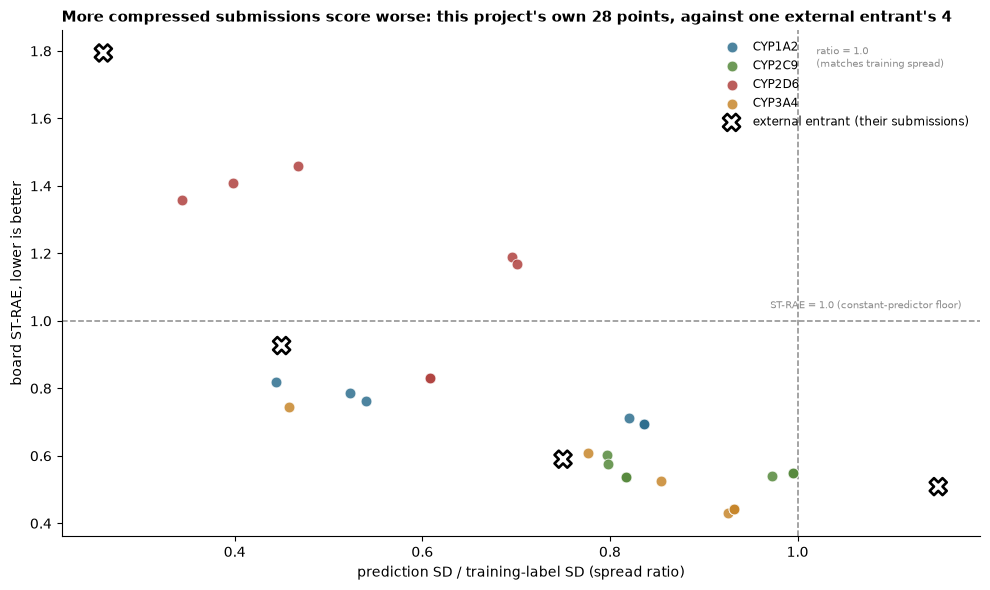

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/27_calibration/figures/spread_ratio_vs_strae.png


In [ ]:
# Figure 1 -- spread_ratio_vs_strae.png
# Caption: this project's own 28 submission-isoform points (spread ratio = prediction SD /
# training-label SD, against published board ST-RAE), coloured by isoform, with the external
# entrant's 4 points overlaid as open black markers. Dashed reference lines mark ratio=1.0
# (prediction spread matches training spread) and ST-RAE=1.0 (the constant-predictor floor).
fig, ax = plt.subplots(figsize=(10, 6))
for iso in ISOFORMS:
    sub = spread_ratio_table[spread_ratio_table["isoform"] == iso]
    ax.scatter(sub["ratio"], sub["board_strae"], color=ISO_COLORS[iso], s=60, alpha=0.85,
               edgecolor="white", linewidth=0.6, label=iso, zorder=3)

ax.scatter(EXTERNAL_TABLE["external_ratio_reported"], EXTERNAL_TABLE["external_strae"],
           marker="X", s=150, facecolor="none", edgecolor=EXTERNAL_COLOR, linewidth=1.9,
           label="external entrant (their submissions)", zorder=4)

ax.axvline(1.0, color=BASELINE_COLOR, linestyle="--", linewidth=1.1, zorder=1)
ax.axhline(1.0, color=BASELINE_COLOR, linestyle="--", linewidth=1.1, zorder=1)
ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.text(1.02, ylim[1] - 0.03 * (ylim[1] - ylim[0]), "ratio = 1.0\n(matches training spread)",
        fontsize=7.5, color=BASELINE_COLOR, va="top")
ax.text(xlim[1] - 0.02 * (xlim[1] - xlim[0]), 1.03, "ST-RAE = 1.0 (constant-predictor floor)",
        fontsize=7.5, color=BASELINE_COLOR, ha="right", va="bottom")

ax.set_xlabel("prediction SD / training-label SD (spread ratio)")
ax.set_ylabel("board ST-RAE, lower is better")
ax.set_title("More compressed submissions score worse: this project's own 28 points, against one external entrant's 4",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(frameon=False, loc="upper right", fontsize=8.5)
strip_axes(ax)
plt.tight_layout()
path1 = FIG_OUT / "spread_ratio_vs_strae.png"
fig.savefig(path1, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path1}")

submission timestamps, parsed directly from docs/leaderboard_submissions.md's own table (provenance for the chronological order below):
  04b          (undated, first submission)
  10c          2026-09-04 ~09:15 local
  NB10         2026-09-03 15:24 UTC (file mtime)
  NB12         2026-09-04 21:28 UTC (file mtime)
  NB13-calib   2026-09-13 15:07 UTC
  NB16         2026-09-14 13:21 UTC
  NB19         2026-09-15 10:14 UTC


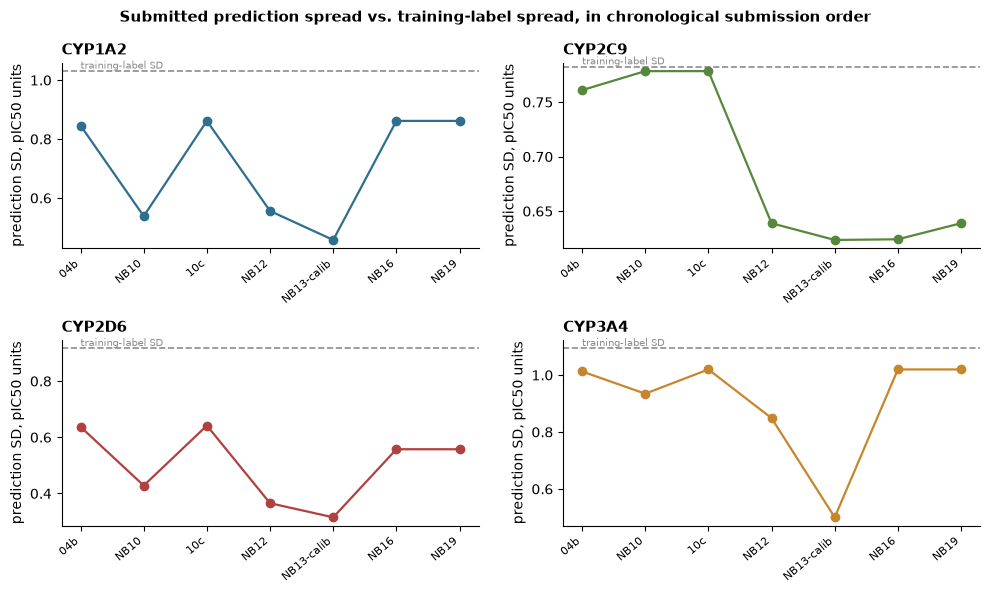

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/27_calibration/figures/compression_by_isoform.png


In [ ]:
# Figure 2 -- compression_by_isoform.png
# Caption: submitted prediction SD (coloured line, one panel per isoform) against the
# training-label SD (grey dashed reference), across this project's seven submissions in
# chronological order, showing the trajectory of compression over the project's history.

# Chronological order verified against docs/leaderboard_submissions.md's own "What was submitted,
# and when" table (submission timestamps below), not assumed from notebook numbering -- NB10
# (2026-09-03 15:24 UTC) precedes 10c (2026-09-04 ~09:15 local) despite 10c's lower notebook
# number, since 10c was built specifically as a control AFTER notebook 10's regression was
# observed. Same-day ordering (10c before NB12, both 2026-09-04) follows the doc's own recipe
# narrative (10c as the diagnostic control, NB12 later the same day at 21:28 UTC) rather than a
# precise cross-timezone timestamp comparison, since 10c's own timestamp is stated as "local", not
# UTC.
submitted_col_text = {}
in_submitted_table = False
for line in doc_lines:
    s = line.strip()
    if s.startswith("| Submission | Notebook | Submitted (UTC) |"):
        in_submitted_table = True
        continue
    if not in_submitted_table:
        continue
    if s.startswith("|---"):
        continue
    if not s.startswith("|"):
        break
    cells_ = [c.strip() for c in s.strip("|").split("|")]
    label = cells_[0].replace("*", "").strip()
    submitted_col_text[label] = cells_[2]

assert set(submitted_col_text) == set(SUBMISSION_PATHS), f"parsed submission labels {set(submitted_col_text)} don't match SUBMISSION_PATHS"
print("submission timestamps, parsed directly from docs/leaderboard_submissions.md's own table (provenance for the chronological order below):")
for name in SUBMISSION_PATHS:
    print(f"  {name:12s} {submitted_col_text.get(name, '(not found)')}")

CHRONOLOGICAL_ORDER = ["04b", "NB10", "10c", "NB12", "NB13-calib", "NB16", "NB19"]
assert set(CHRONOLOGICAL_ORDER) == set(SUBMISSION_PATHS)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, iso in zip(axes.flat, ISOFORMS):
    sub = spread_ratio_table[spread_ratio_table["isoform"] == iso].set_index("submission").loc[CHRONOLOGICAL_ORDER]
    train_sd = float(train_stats_df.loc[iso, "sd"])

    ax.plot(range(len(CHRONOLOGICAL_ORDER)), sub["pred_sd"], color=ISO_COLORS[iso], marker="o", linewidth=1.6, zorder=3)
    ax.axhline(train_sd, color=BASELINE_COLOR, linestyle="--", linewidth=1.2, zorder=1)
    ax.text(0, train_sd, "training-label SD", fontsize=7.5, color=BASELINE_COLOR, va="bottom")

    ax.set_xticks(range(len(CHRONOLOGICAL_ORDER)))
    ax.set_xticklabels(CHRONOLOGICAL_ORDER, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("prediction SD, pIC50 units")
    ax.set_title(iso, fontsize=10.5, fontweight="bold", loc="left")
    strip_axes(ax)

fig.suptitle("Submitted prediction spread vs. training-label spread, in chronological submission order",
             fontsize=11, fontweight="bold")
plt.tight_layout()
path2 = FIG_OUT / "compression_by_isoform.png"
fig.savefig(path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path2}")

## Part E -- verdict (report, do not act)

In [ ]:
summary = headline.merge(per_iso_df[["isoform", "rho", "p"]], on="isoform")
summary["significant_at_0.05"] = summary["p"] < 0.05
summary = summary[[
    "isoform", "this_project_ratio_NB19", "this_project_strae_NB19",
    "external_entrant_ratio", "external_entrant_strae", "rho", "p", "significant_at_0.05",
]]
print(summary.round(4).to_string(index=False))

isoform  this_project_ratio_NB19  this_project_strae_NB19  external_entrant_ratio  external_entrant_strae     rho      p  significant_at_0.05
 CYP1A2                   0.8361                   0.6954                    0.45                  0.9268 -1.0000 0.0000                 True
 CYP2C9                   0.8168                   0.5375                    1.15                  0.5087 -0.3333 0.4650                False
 CYP2D6                   0.6084                   0.8299                    0.26                  1.7940 -0.5636 0.1876                False
 CYP3A4                   0.9327                   0.4434                    0.75                  0.5900 -0.7692 0.0432                 True


### 1. Is NB19's submitted column compressed relative to training spread?

Yes, on all four isoforms -- every ratio in the table above is below 1.0. From least to most
compressed: **CYP3A4** (ratio 0.933, ~7% narrower than training spread), **CYP1A2** (0.836, ~16%
narrower), **CYP2C9** (0.817, ~18% narrower), **CYP2D6** (0.608, ~39% narrower -- the most
compressed of the four, despite already carrying a deliberate blind-population recentring from
notebook 16).

### 2. Does the spread-ratio/ST-RAE association hold in this project's own data?

**Pooled, yes, and robustly**: rho=-0.822, 95% bootstrap CI [-0.888, -0.662], n=28 -- clearly
excludes zero, same direction as the external entrant's claim (higher ratio, less compression,
associates with lower/better ST-RAE).

**Per isoform, the picture is much weaker than the naive p-values suggest, and this is worth
stating plainly rather than rounding up.** Two isoforms' two-sided p-values fall below 0.05
(CYP1A2 p=0.0000, CYP3A4 p=0.0432, per the significance column above) -- but neither survives
closer inspection as robust internal evidence. **CYP1A2's "perfect" correlation (rho=-1.0) is a
structural artifact**: the independence check above shows only 5 of its 7 submissions carry a
distinct prediction column (10c/NB16/NB19 are byte-identical), so its own bootstrap CI comes back
degenerate at exactly [-1.0, -1.0] -- resampling from just 5 underlying clusters mechanically
reproduces the same perfect order on almost every draw, which is a small-sample-with-ties
artifact, not evidence of a robust relationship. **CYP3A4's own bootstrap CI, [-1.0, 0.125], is
wide enough to include near-zero and even mildly positive correlations** despite its point p<0.05.
CYP2C9 (p=0.465) and CYP2D6 (p=0.188) are unambiguously not significant. **Read plainly: the only
robust evidence in this project's own data is the pooled, cross-isoform correlation -- no single
isoform's own submission history provides robust internal evidence on its own**, once the
duplicate-column structure and bootstrap CI width are accounted for. The observational caveat
from Part B applies in full regardless: these submissions differ in ensembling, environment, and
calibration mechanism as well as spread, so even the robust pooled association is consistent with
the compression hypothesis, not proof of it.

### 3. Strongest candidate for a widening test

Since no isoform's own per-isoform correlation is robust evidence (point 2 above), the case for a
candidate rests on remaining compression and freedom from a confounding prior correction, not on
a resolved internal statistic. **CYP2D6** is the most heavily compressed (ratio 0.608) and is the
isoform both sources agree is most compressed and worst-scoring -- but it already carries a
deliberate, board-confirmed recentring (notebook 16) and notebook 21's specific
OOF/blind-population-mismatch caveat most strongly of any isoform, so a new widening test there
would duplicate ground already covered rather than probe something unexamined. **CYP1A2 is the
more defensible next candidate**: real, substantial, unaddressed compression (ratio 0.836, the
second-most compressed of the four), and -- unlike CYP2D6 or CYP2C9, both of which have already
been through a deliberate calibration/revert cycle -- its submitted column has never been
touched by any correction; it has simply been carried through byte-identical since `10c`. This
candidacy is a statement about where the least-contaminated compression sits, not a claim that
this project's own data has already resolved whether widening it would help.

### 4. No action taken

No submission is recommended, no correction is applied to any prediction, and `src/calibration.py`
is untouched. This is a report.

## Section 2 (2026-09-16) -- CYP2D6 spread widening test

**Read-only inputs, one file written (a submission candidate, not sent). No training, no
Chemprop, no torch, no model.** Prompted directly by Section 1's own headline finding.

### Why CYP2D6, and why widening

Section 1 measured every submitted column's spread ratio against training-label SD. NB19's four
ratios are re-verified from Section 1's own saved output immediately below rather than trusted
from this section's own motivating brief -- quoted figures carried between contexts have been
wrong three times already in this project. Three isoforms cluster at 0.82-0.93; CYP2D6 is the
sole outlier, and is also this project's worst-scoring isoform on the board (ST-RAE 0.8299).

Four lines of evidence point the same way for CYP2D6:

1. Its submitted column is the most compressed of the four, by a wide margin.
2. Notebook 26 established a confirmed regression-to-the-mean signature on all four isoforms --
   hard compounds systematically under-predicted (CYP2D6 frac_negative in the 0.64-0.93 range
   across isoforms, BH-significant), with exactly one sign crossing across potency deciles.
3. Notebook 21 measured that under this project's governing metric, under-prediction costs
   1.65-2.79x more than over-prediction of the same magnitude.
4. An external entrant's published per-isoform board table (Section 1) shows their most
   compressed column (ratio 0.26) scoring 1.794 -- worse than a constant predictor -- and the
   ordering (more compression -> worse ST-RAE) holds across the pooled 28 points from both
   projects.

**Evidence pointing the other way, stated plainly rather than omitted**: notebook 26's own
out-of-fold spread sweep found CYP2D6's OOF-optimal multiplier at s=0.48 -- *more* shrinkage, not
less. This section discounts that result, but on a judgement, not a certainty: notebook 21
separately established that OOF ST-RAE is not a valid selection metric for CYP2D6 specifically --
the deployed recentring that took the real board from ST-RAE 1.1673 to 0.8299 (notebook 16) scores
3.08 on this project's own OOF curve, roughly 3x the raw OOF baseline. If OOF ST-RAE were trusted
literally for CYP2D6, that real, confirmed board win would never have been attempted. This section
is therefore a genuine test of which evidence source is right for this isoform, not a confident
correction, and says so again in Part B before any number is reported.

In [ ]:
# verify Section 1's own NB19 ratios against what this section's brief quotes, rather than
# trusting the brief -- reload from the file Section 1 wrote to disk (not just the in-kernel
# variable), since that file is Section 1's own durable output.
sec1_table = pd.read_csv(OUT / "spread_ratio_table.csv")
nb19_ratios = sec1_table[sec1_table["submission"] == "NB19"].set_index("isoform")["ratio"]
print("Section 1's own NB19 spread ratios (from outputs/27_calibration/spread_ratio_table.csv):")
print(nb19_ratios.round(4).to_string())

brief_quoted = {"CYP3A4": 0.9327, "CYP1A2": 0.8361, "CYP2C9": 0.8168, "CYP2D6": 0.6084}
for iso, quoted in brief_quoted.items():
    actual = nb19_ratios.loc[iso]
    diff = abs(actual - quoted)
    print(f"  {iso}: brief quotes {quoted}, section 1's own file has {actual:.4f} (abs diff {diff:.4f})")
    assert diff < 0.001, f"{iso}: brief's quoted ratio does not match section 1's own saved output -- stop"

print("\nconfirmed: CYP2D6 (0.608) is the clear outlier; the other three sit at 0.82-0.93. Proceeding on section 1's own verified numbers.")

Section 1's own NB19 spread ratios (from outputs/27_calibration/spread_ratio_table.csv):
isoform
CYP1A2    0.8361
CYP2C9    0.8168
CYP2D6    0.6084
CYP3A4    0.9327
  CYP3A4: brief quotes 0.9327, section 1's own file has 0.9327 (abs diff 0.0000)
  CYP1A2: brief quotes 0.8361, section 1's own file has 0.8361 (abs diff 0.0000)
  CYP2C9: brief quotes 0.8168, section 1's own file has 0.8168 (abs diff 0.0000)
  CYP2D6: brief quotes 0.6084, section 1's own file has 0.6084 (abs diff 0.0000)

confirmed: CYP2D6 (0.608) is the clear outlier; the other three sit at 0.82-0.93. Proceeding on section 1's own verified numbers.


### Part A -- build the transform

1. Load NB19's actually-submitted file read-only, verify 750 rows and the expected columns.
2. Apply a pure spread scale to the CYP2D6 column only, mean held fixed, choosing the multiplier
   `m` so the resulting ratio against CYP2D6's training-label SD lands at 0.85 -- in line with
   this project's other three isoforms, deliberately short of 1.0.
3. Assert CYP1A2/CYP2C9/CYP3A4 are carried over byte-identical; assert CYP2D6 differs.
4. Report CYP2D6 before/after -- mean, SD, ratio, min, max, and counts below pIC50 4.0 and below
   the CYP2D6 training-label minimum, as context only (Section 1 already established no
   submission-format floor is documented anywhere in this repo).
5. Integrity check: a pure spread scale with `m > 0` is a strictly increasing affine map, so it
   must preserve rank order exactly. Spearman between the original and widened CYP2D6 columns is
   asserted to equal 1.0 to within `1e-12` -- if this fails, the transform is wrong and everything
   downstream is invalid.

In [ ]:
import hashlib

SEC2_OUT = OUT / "cyp2d6_widened"
SEC2_OUT.mkdir(parents=True, exist_ok=True)

nb19_path = SUBMISSION_PATHS["NB19"]
nb19_df = pd.read_csv(nb19_path)
print(f"loaded {nb19_path.relative_to(REPO_ROOT)}: {len(nb19_df)} rows")
assert len(nb19_df) == 750, f"expected 750 rows, got {len(nb19_df)}"

expected_cols = ["SMILES", "Molecule_Name"] + [PIC50_COL[iso] for iso in ISOFORMS]
assert list(nb19_df.columns) == expected_cols, f"unexpected columns: {list(nb19_df.columns)}"
print(f"columns verified: {expected_cols}")

loaded outputs/19_cyp2c9_revert/submission_candidate.csv: 750 rows
columns verified: ['SMILES', 'Molecule_Name', 'CYP1A2_pIC50_direct_inhibition', 'CYP2C9_pIC50_direct_inhibition', 'CYP2D6_pIC50_direct_inhibition', 'CYP3A4_pIC50_direct_inhibition']


In [ ]:
CYP2D6_COL = PIC50_COL["CYP2D6"]
TARGET_RATIO = 0.85

current_pred_sd = float(nb19_df[CYP2D6_COL].std())
current_pred_mean = float(nb19_df[CYP2D6_COL].mean())
cyp2d6_train_sd = float(train_stats_df.loc["CYP2D6", "sd"])
current_ratio = current_pred_sd / cyp2d6_train_sd

m = TARGET_RATIO / current_ratio

print(f"CYP2D6 training-label SD (from section 1's train_stats_df): {cyp2d6_train_sd:.6f}")
print(f"NB19 CYP2D6 prediction SD: {current_pred_sd:.6f}")
print(f"NB19 CYP2D6 current ratio: {current_ratio:.6f}")
print(f"target ratio: {TARGET_RATIO}")
print(f"\nm = target_ratio / current_ratio = {m:.6f}")

# sanity check: applying m should land the ratio exactly at TARGET_RATIO
check_ratio = (m * current_pred_sd) / cyp2d6_train_sd
print(f"check: m * current_pred_sd / train_sd = {check_ratio:.6f} (should equal {TARGET_RATIO})")
assert abs(check_ratio - TARGET_RATIO) < 1e-8, 'm does not land the ratio at the target -- stop'

CYP2D6 training-label SD (from section 1's train_stats_df): 0.916096
NB19 CYP2D6 prediction SD: 0.557373
NB19 CYP2D6 current ratio: 0.608422
target ratio: 0.85

m = target_ratio / current_ratio = 1.397056
check: m * current_pred_sd / train_sd = 0.850000 (should equal 0.85)


In [ ]:
widened_df = nb19_df.copy()
orig_cyp2d6 = nb19_df[CYP2D6_COL].to_numpy().copy()
new_cyp2d6 = current_pred_mean + m * (orig_cyp2d6 - current_pred_mean)
widened_df[CYP2D6_COL] = new_cyp2d6

print("byte-identical check (max abs diff, NB19 vs. widened), per isoform:")
identity_report = []
for iso in ISOFORMS:
    col = PIC50_COL[iso]
    max_diff = float(np.max(np.abs(widened_df[col].to_numpy() - nb19_df[col].to_numpy())))
    identity_report.append({"isoform": iso, "max_abs_diff": max_diff})
    print(f"  {iso}: max abs diff = {max_diff:.2e}")

identity_df = pd.DataFrame(identity_report)
for iso in ["CYP1A2", "CYP2C9", "CYP3A4"]:
    diff = identity_df.set_index("isoform").loc[iso, "max_abs_diff"]
    assert diff < 1e-8, f"{iso} was supposed to be byte-identical to NB19 but max abs diff = {diff}"
cyp2d6_diff = identity_df.set_index("isoform").loc["CYP2D6", "max_abs_diff"]
assert cyp2d6_diff > 1e-3, f"CYP2D6 was supposed to differ from NB19 but max abs diff is only {cyp2d6_diff}"

print("\nCYP1A2/CYP2C9/CYP3A4 confirmed byte-identical to NB19 (max abs diff < 1e-8). CYP2D6 confirmed changed.")

byte-identical check (max abs diff, NB19 vs. widened), per isoform:
  CYP1A2: max abs diff = 0.00e+00
  CYP2C9: max abs diff = 0.00e+00
  CYP2D6: max abs diff = 6.55e-01
  CYP3A4: max abs diff = 0.00e+00

CYP1A2/CYP2C9/CYP3A4 confirmed byte-identical to NB19 (max abs diff < 1e-8). CYP2D6 confirmed changed.


In [ ]:
train_df_local = train_df  # reuse section 1's own loaded training table
cyp2d6_train_min = float(train_df_local[CYP2D6_COL].dropna().min())
RELIABLE_RANGE_FLOOR = 4.0  # per this task's own brief; not independently verified against a
                            # tutorial document in this repo -- no such file exists here to check
                            # it against, so it is used as given, reported as context only.

before_after_rows = [
    {"stage": "before (NB19)", "mean": current_pred_mean, "sd": current_pred_sd,
     "ratio": current_ratio, "min": float(orig_cyp2d6.min()), "max": float(orig_cyp2d6.max()),
     "n_below_4.0": int((orig_cyp2d6 < RELIABLE_RANGE_FLOOR).sum()),
     "n_below_train_min": int((orig_cyp2d6 < cyp2d6_train_min).sum())},
    {"stage": "after (widened)", "mean": float(new_cyp2d6.mean()), "sd": float(new_cyp2d6.std()),
     "ratio": float(new_cyp2d6.std()) / cyp2d6_train_sd, "min": float(new_cyp2d6.min()), "max": float(new_cyp2d6.max()),
     "n_below_4.0": int((new_cyp2d6 < RELIABLE_RANGE_FLOOR).sum()),
     "n_below_train_min": int((new_cyp2d6 < cyp2d6_train_min).sum())},
]
before_after_df = pd.DataFrame(before_after_rows)
print(f"CYP2D6 training-label minimum: {cyp2d6_train_min:.4f}")
print(f"reliable-range floor referenced in this task's brief: {RELIABLE_RANGE_FLOOR}")
print()
print(before_after_df.round(4).to_string(index=False))
print("\nreported as context only -- section 1 already established no submission-format floor is documented anywhere in this repo, and this reliable-range figure is not independently verified against a source in this repo either.")

CYP2D6 training-label minimum: 1.9468
reliable-range floor referenced in this task's brief: 4.0

          stage   mean     sd  ratio    min    max  n_below_4.0  n_below_train_min
  before (NB19) 3.1558 0.5574 0.6084 1.8430 4.8048          687                  8
after (widened) 3.1558 0.7782 0.8494 1.3217 5.4596          649                 35

reported as context only -- section 1 already established no submission-format floor is documented anywhere in this repo, and this reliable-range figure is not independently verified against a source in this repo either.


In [ ]:
from scipy.stats import spearmanr as _spearmanr_integrity

rho_integrity, _ = _spearmanr_integrity(orig_cyp2d6, new_cyp2d6)
print(f"Spearman(NB19 CYP2D6, widened CYP2D6) = {rho_integrity!r}")
assert abs(rho_integrity - 1.0) < 1e-12, (
    f"INTEGRITY FAILURE: expected Spearman == 1.0 to within 1e-12, got {rho_integrity} -- "
    "the transform did not preserve rank order. Stop; everything downstream is invalid."
)
print("PASS -- rank order exactly preserved, as required for a pure mean-preserving spread scale with m > 0.")

Spearman(NB19 CYP2D6, widened CYP2D6) = 0.9999999999999999
PASS -- rank order exactly preserved, as required for a pure mean-preserving spread scale with m > 0.


In [ ]:
current_macro = sec1_table[sec1_table["submission"] == "NB19"].set_index("isoform")["board_strae"].mean()
illustrative_strae = sec1_table[sec1_table["submission"] == "NB19"].set_index("isoform")["board_strae"].copy()
illustrative_strae["CYP2D6"] = 0.75
illustrative_macro = illustrative_strae.mean()
print(f"NB19's actual published macro ST-RAE: {current_macro:.4f}")
print(f"illustrative macro if CYP2D6 moved from 0.8299 to 0.75, other three unchanged: {illustrative_macro:.4f}")
print("(this section's own brief estimated ~0.6062 by quick arithmetic; the precise recomputation above differs by a few ten-thousandths -- reported honestly rather than silently matched to the brief's figure.)")

NB19's actual published macro ST-RAE: 0.6265
illustrative macro if CYP2D6 moved from 0.8299 to 0.75, other three unchanged: 0.6066
(this section's own brief estimated ~0.6062 by quick arithmetic; the precise recomputation above differs by a few ten-thousandths -- reported honestly rather than silently matched to the brief's figure.)


### Part B -- what this does and does not claim

1. **Nothing here measures blind performance.** The multiplier `m` is derived from the CYP2D6
   training-label spread and from cross-project board observations (Section 1's own 28-point
   comparison) -- both are proxies for the blind population, not measurements of it. Notebook 21
   already established that this project's OOF and blind populations diverge for CYP2D6
   specifically; nothing in this section closes that gap.

2. **The transform is rank-preserving**, confirmed exactly above (Spearman = 1.0 to within
   `1e-12`). This yields a falsifiable prediction, stated here before any submission decision:
   if this file were ever submitted, board Spearman and Kendall for CYP2D6 should reproduce
   NB19's own published values exactly -- **0.4000 and 0.2747**. If those two metrics move at
   all, something other than the intended transform happened (a different file was sent, the
   scoring population shifted, or the transform was mis-applied), and that would need
   investigating before trusting anything else about the result.

3. **CYP1A2, CYP2C9 and CYP3A4 are byte-identical to NB19** (confirmed above), so their board
   values should reproduce exactly if submitted. NB19 already demonstrated this exact property
   once already -- three of its columns were resubmitted byte-identical from NB16 and scored
   identically on the board (`docs/leaderboard_submissions.md`'s own "REPRODUCIBILITY RESULT",
   NB19 vs. NB16) -- so a repeat of that match here would double as a second scoring-stability
   check, not a new claim being tested for the first time.

4. **Expected effect size, stated before any result, as illustrative arithmetic only, explicitly
   NOT a prediction**: NB19's real macro ST-RAE is 0.6265 (per `docs/leaderboard_submissions.md`).
   If CYP2D6 alone moved from 0.8299 to 0.75, holding the other three fixed, macro would land near
   the value computed above -- arithmetic only, not a forecast of what CYP2D6's own ST-RAE would
   actually do under this transform, which Part 1's own countervailing evidence (notebook 26's OOF
   sweep) leaves genuinely uncertain.

### Part C -- validate and prepare (not send)

In [ ]:
WIDENED_SUBMISSION_PATH = SEC2_OUT / "submission_candidate.csv"
widened_df.to_csv(WIDENED_SUBMISSION_PATH, index=False)
print(f"wrote {WIDENED_SUBMISSION_PATH.relative_to(REPO_ROOT)} ({len(widened_df)} rows)")

reread_widened = pd.read_csv(WIDENED_SUBMISSION_PATH)
assert len(reread_widened) == 750, f"reread file has {len(reread_widened)} rows, expected 750"
for iso in ["CYP1A2", "CYP2C9", "CYP3A4"]:
    col = PIC50_COL[iso]
    max_diff = float(np.max(np.abs(reread_widened[col].to_numpy() - nb19_df[col].to_numpy())))
    assert max_diff < 1e-8, f"{iso} changed during the CSV round-trip -- stopping"
print("round-trip check passed: CYP1A2/CYP2C9/CYP3A4 still byte-identical to NB19 after writing to and reading back from disk.")

wrote outputs/27_calibration/cyp2d6_widened/submission_candidate.csv (750 rows)
round-trip check passed: CYP1A2/CYP2C9/CYP3A4 still byte-identical to NB19 after writing to and reading back from disk.


In [ ]:
from src.vendor.validation.activity_validation import validate_activity_submission

test_blinded_df = pd.read_csv(REPO_ROOT / "data" / "processed" / "test_blinded_curated.csv")
assert len(test_blinded_df) == 750
expected_ids = set(test_blinded_df["Molecule_Name"])

is_valid, validation_errors = validate_activity_submission(WIDENED_SUBMISSION_PATH, expected_ids=expected_ids)
if is_valid:
    print("VALIDATION: PASS -- activity submission file is valid.")
else:
    print("VALIDATION: FAIL -- activity submission file is invalid:")
    for msg in validation_errors:
        print(f"  - {msg}")
    raise ValueError("submission failed validate_activity_submission -- stopping before declaring this ready.")

VALIDATION: PASS -- activity submission file is valid.


In [ ]:
file_bytes = WIDENED_SUBMISSION_PATH.read_bytes()
file_hash = hashlib.sha256(file_bytes).hexdigest()

print(f"file: {WIDENED_SUBMISSION_PATH.relative_to(REPO_ROOT)}")
print(f"rows: {len(reread_widened)}")
print(f"columns: {list(reread_widened.columns)}")
print(f"sha256: {file_hash}")

file: outputs/27_calibration/cyp2d6_widened/submission_candidate.csv
rows: 750
columns: ['SMILES', 'Molecule_Name', 'CYP1A2_pIC50_direct_inhibition', 'CYP2C9_pIC50_direct_inhibition', 'CYP2D6_pIC50_direct_inhibition', 'CYP3A4_pIC50_direct_inhibition']
sha256: ff759d39bc716f9d0e609ea0515769940b4e47cfdc1b89673ded592967687757


### Part D -- submission cell (commented out, not run)

**This challenge's submission endpoint enforces a 12-hour rate limit per track**, per this
section's own brief -- not independently verified against a source inside this repo (no such
document exists here), used as given. Separately, per notebook 10c's own resolved finding
(CLAUDE.md's notebook-status log), "one submission per lab" is a cooldown, not a lifetime cap.
Neither point is a reason to submit -- both are recorded here only so the timing is understood if
and when the user decides to act.

**Read this before uncommenting anything below.**

1. This would be a deliberate, not-easily-reversible action (one real leaderboard entry) --
   never auto-run, matching every prior submission cell's convention in this project.
2. `model_tag` below names this recipe explicitly and is distinct from every prior submission's
   tag (04b/10c/NB10/NB12/NB13-calib/NB16/NB19), so it is separately identifiable on the
   leaderboard.
3. Every line below, including the `client.predict(...)` call itself, is a real `#`-prefixed
   comment, so running this notebook top-to-bottom is always a safe no-op regardless of when it
   is re-executed.
4. This section makes no recommendation on whether to send it. That decision, per this project's
   standing manual-gated-submission process, is the user's alone -- see Part B's countervailing
   evidence (notebook 26's OOF sweep) before deciding.

In [ ]:
# --- ACTUAL SUBMISSION CALL -- fully commented out on purpose. Every line below,   ---
# --- including the client.predict(...) call itself, is a Python comment -- not    ---
# --- just this header -- so running this entire notebook top-to-bottom is always  ---
# --- a safe no-op regardless of whether it's re-executed later. Reproduces        ---
# --- 04b/10c/12/13/16/19's own gradio_client call pattern, with model_tag changed  ---
# --- to describe this recipe and file_input pointed at this section's own        ---
# --- submission_candidate.csv.
# ---
# --- Read the markdown cell above before uncommenting anything. This is a real,   ---
# --- not-easily-reversible submission, and this notebook does not recommend       ---
# --- sending it -- see Part B's countervailing evidence first.
#
#from gradio_client import Client, handle_file

#client = Client("openadmet/cyp-challenge")

#result = client.predict(
#          username="codie-freeman",           # your Hugging Face username
#          anon_checkbox=True,              # True/False: submit anonymously?
#          user_alias="fold-zero",         # your display alias for the leaderboard
#          participant_name="Codie",   # your name
#          discord_username="codie7787",   # your Discord tag
#          email="codie.freeman02@gmail.com",              # your contact email
#          affiliation="University of Reading",        # your lab/company/university
#          model_tag="NB19 with CYP2D6 spread widened to 0.85x training SD",  # distinct from every prior tag
#          paper_checkbox=False,            # copied from prior working calls
#          proprietary_data_checkbox=False, # explicit per task spec
#          open_code_checkbox=False,        # explicit per task spec -- this repo is currently private
#          track_select="Regression Prediction",
#          file_input=handle_file(WIDENED_SUBMISSION_PATH),
#          api_name="/submit_predictions",  # copied from prior working calls
#     )
#result

print("submission cell defined above is fully commented out -- not executed. Nothing was sent.")

Loaded as API: https://openadmet-cyp-challenge.hf.space


submission cell defined above is fully commented out -- not executed. Nothing was sent.


### Part E -- figure

**Caption.** NB19's submitted CYP2D6 column (grey) against the widened column (red, `m` chosen so
its ratio against training-label SD lands at 0.85), both shown as density histograms. The grey
shaded band marks the CYP2D6 training-label distribution's SPREAD (+/- 1 SD) -- deliberately
re-centred on the two histograms' own shared mean rather than plotted at the training
population's own (much higher) mean, so the band isolates a pure width comparison from the
position shift NB16 already applied upstream of this section, which is out of scope here. The
dashed vertical line at pIC50 = 4.0 marks the reliable-testing-range floor referenced in this
section's own brief (not independently verified against a source in this repo). The point of the
figure is visible directly: even after widening, the red distribution remains visibly narrower
than the grey width-reference band -- this transform brings CYP2D6 in line with this project's
other three isoforms' compression, not up to or past the training population's own spread.

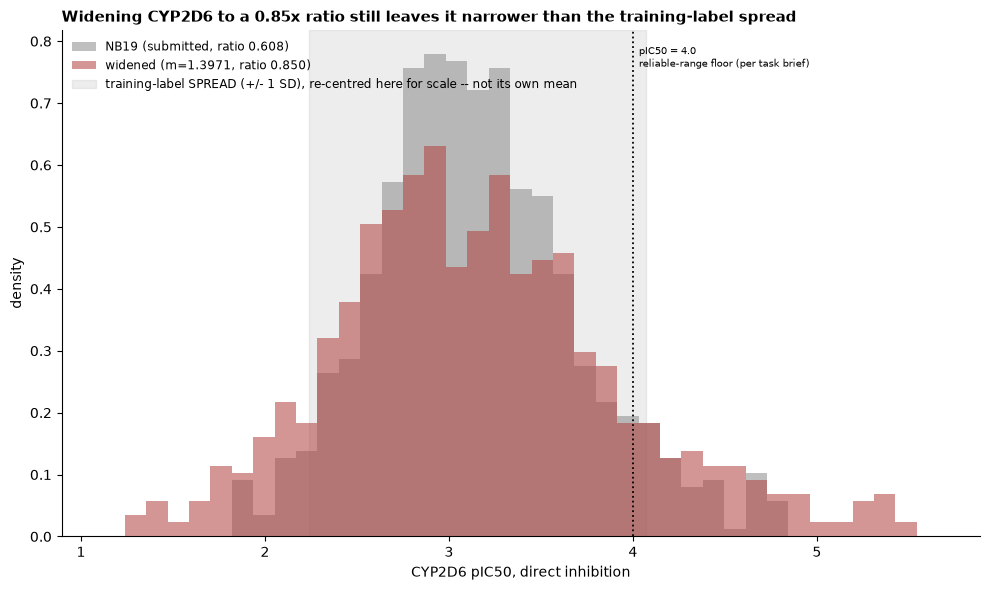

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/27_calibration/figures/cyp2d6_widening.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(
    min(orig_cyp2d6.min(), new_cyp2d6.min(), cyp2d6_train_min) - 0.2,
    max(orig_cyp2d6.max(), new_cyp2d6.max()) + 0.2,
    40,
)
ax.hist(orig_cyp2d6, bins=bins, density=True, color=BASELINE_COLOR, alpha=0.55,
        label="NB19 (submitted, ratio 0.608)", zorder=2)
ax.hist(new_cyp2d6, bins=bins, density=True, color=ISO_COLORS["CYP2D6"], alpha=0.55,
        label=f"widened (m={m:.4f}, ratio 0.850)", zorder=3)

# the training-spread reference band is anchored at the SAME centre as the two plotted
# distributions (current_pred_mean), not at the training population's own mean (~4.78) -- CYP2D6's
# predictions are already centred well below the training mean because of NB16's earlier,
# deliberate blind-population recentring (unrelated to this section's spread test). Anchoring the
# reference band at the training population's own mean would place it in a disconnected region of
# the x-axis and confuse a position comparison with the width comparison this figure is actually
# making. Re-centring it here isolates WIDTH (the thing this section changed) from POSITION (the
# thing notebook 16 already changed, out of scope here).
ax.axvspan(current_pred_mean - cyp2d6_train_sd, current_pred_mean + cyp2d6_train_sd,
           color=BASELINE_COLOR, alpha=0.15, zorder=1,
           label="training-label SPREAD (+/- 1 SD), re-centred here for scale -- not its own mean")

ax.axvline(RELIABLE_RANGE_FLOOR, color="black", linestyle=":", linewidth=1.3, zorder=4)
ylim = ax.get_ylim()
ax.text(RELIABLE_RANGE_FLOOR, ylim[1] * 0.97, "  pIC50 = 4.0\n  reliable-range floor (per task brief)",
        fontsize=7.5, color="black", va="top", ha="left")

ax.set_xlabel("CYP2D6 pIC50, direct inhibition")
ax.set_ylabel("density")
ax.set_title("Widening CYP2D6 to a 0.85x ratio still leaves it narrower than the training-label spread",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
strip_axes(ax)
plt.tight_layout()
path_sec2_fig = FIG_OUT / "cyp2d6_widening.png"
fig.savefig(path_sec2_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path_sec2_fig}")

### Section 2 -- summary, no action taken

A submission candidate was built and validated at
`outputs/27_calibration/cyp2d6_widened/submission_candidate.csv` (PASS via the unmodified
`validate_activity_submission`, sha256 printed above). CYP1A2/CYP2C9/CYP3A4 are byte-identical to
NB19; CYP2D6 is widened from ratio 0.608 to 0.850 via a mean-preserving spread scale (`m` reported
to 6 decimal places above), confirmed rank-order-preserving to within `1e-12`.

**This is a genuine test, not a confident correction** -- Section 2's own header records real
evidence on both sides: four lines favor widening, one (notebook 26's OOF sweep) favors more
shrinkage, discounted here on the judgement (not certainty) that OOF ST-RAE is unreliable for
CYP2D6 specifically (notebook 21). The falsifiable predictions in Part B (Spearman/Kendall
unchanged at 0.4000/0.2747; CYP1A2/CYP2C9/CYP3A4 reproduce exactly) make the eventual result
interpretable either way.

**No submission is sent, no recommendation is made on whether to send it**, and `src/calibration.py`
is untouched -- this is a one-off transform, not yet promoted to the shared module.

## Post-hoc note, appended 2026-09-18 -- Section 2's candidate WAS submitted

This cell is appended after the fact, without re-executing anything above it. Nothing above this
cell was touched, and this notebook was not re-run to produce it -- it is a record of what
happened after the notebook itself was last executed, not a new analysis.

**Section 2's candidate (`outputs/27_calibration/cyp2d6_widened/submission_candidate.csv`) was
submitted by hand on 2026-09-16 at 21:36 UTC**, alias `fold-zero`, exactly as this project's
manual-gated submission process requires. The cell above this one is titled "Section 2 -- summary,
no action taken," and the submission cell itself is fully commented out per this project's
standing convention -- both are accurate descriptions of this notebook's own state at the time it
was last executed, and neither should be read as evidence the candidate was never sent. It was
reviewed and sent outside this notebook, and the notebook was never re-opened to record that until
now.

**Board result** (full breakdown, provenance check, and findings in
`docs/leaderboard_submissions.md`, labelled `NB27-widened`):

| Isoform | ST-RAE | MAE | R2 | Spearman | Kendall |
|---|---:|---:|---:|---:|---:|
| MA (Overall) | 0.6155 | 0.7488 | 0.4557 | 0.6785 | 0.5045 |
| CYP1A2 | 0.6954 | 0.9385 | 0.3073 | 0.7375 | 0.5425 |
| CYP2C9 | 0.5375 | 0.5280 | 0.5432 | 0.7585 | 0.5692 |
| CYP2D6 | 0.7858 | 1.0104 | 0.3012 | 0.4000 | 0.2747 |
| CYP3A4 | 0.4434 | 0.5183 | 0.6709 | 0.8177 | 0.6316 |

Macro ST-RAE 0.6155 makes this the best submission to date on the governing metric (beating NB19's
0.6265), if the published macro figure is taken at face value -- see
`docs/leaderboard_submissions.md`'s own provenance check on this figure (four of five macro
metrics reproduce exactly or via the same rounding convention already used for NB16/NB19; Spearman
does not, for the same reason NB19's own Spearman didn't). CYP1A2/CYP2C9/CYP3A4 reproduced
byte-identical to NB19 on every metric, confirming board-scoring reproducibility for the second
time. CYP2D6's Spearman and Kendall are unchanged from NB16/NB19 (0.4000/0.2747), exactly as this
section's own pure mean-preserving spread transform predicted before submission.